In [3]:
#Required Libraries 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os 
from PIL import Image


In [4]:
base_dir="CIFAR_10_IMAGES"
print(base_dir)

CIFAR_10_IMAGES


In [5]:
classes=["Bird","Cat","Dog"]
print(classes)

['Bird', 'Cat', 'Dog']


In [6]:
X=[] # image data
y=[] # class labels
for class_index, class_name in enumerate(classes):
    folder=os.path.join(base_dir,class_name)
    image_files=[
        f for f in os.listdir(folder) 
        if f.lower().endswith((".png",".jpg",".jpeg"))]
    for image_file in image_files:
        image_path=os.path.join(folder,image_file)
        img=Image.open(image_path).convert("RGB")
        X.append(np.array(img))
        y.append(class_index)



In [7]:
X=np.array(X)
y=np.array(y)
print("X Shape : " , X.shape)
print("y Shape : " , y.shape)


X Shape :  (600, 32, 32, 3)
y Shape :  (600,)


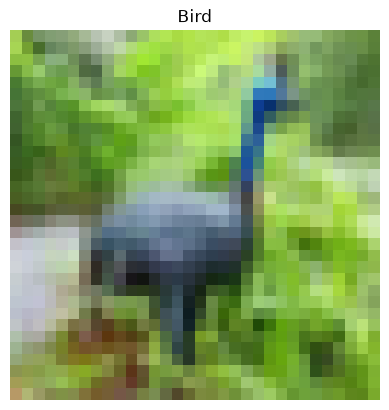

In [8]:
plt.imshow(X[0])
plt.title(classes[y[0]])
plt.axis("off")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y)
X_val,X_test,y_val,y_test=train_test_split(
    X_temp,y_temp, random_state=42,test_size=0.50,stratify=y_temp)

print("X_train Shape :", X_train.shape)
print("y_train Shape :", y_train.shape)

print("X_val Shape   :", X_val.shape)
print("y_val Shape   :", y_val.shape)

print("X_test Shape  :", X_test.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (480, 32, 32, 3)
y_train Shape : (480,)
X_val Shape   : (60, 32, 32, 3)
y_val Shape   : (60,)
X_test Shape  : (60, 32, 32, 3)
y_test Shape  : (60,)


In [10]:
print("Minimum pixel value : " , X_train.min())
print("Maximum pixel value : " , X_train.max())


Minimum pixel value :  0
Maximum pixel value :  255


In [11]:
print("Normalizing the pixel values : ")
X_train=X_train.astype("float32")/255.0
X_val=X_val.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0
print("X_train minimum:", X_train.min())
print("X_train maximum:", X_train.max())

print("X_val minimum:", X_val.min())
print("X_val maximum:", X_val.max())

print("X_test minimum:", X_test.min())
print("X_test maximum:", X_test.max())

Normalizing the pixel values : 
X_train minimum: 0.0
X_train maximum: 1.0
X_val minimum: 0.0
X_val maximum: 1.0
X_test minimum: 0.0
X_test maximum: 1.0


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [13]:
import warnings 
warnings.filterwarnings("ignore")
model=Sequential()
print(model)
model.add(Conv2D(filters=32,
                 kernel_size=(3,3),
                 activation="relu",
                 input_shape=(32,32,3)
                )
         )
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu"))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(3,activation="softmax"))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=["accuracy"])
model.summary()

          

<Sequential name=sequential, built=False>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,404,355 (5.36 MB)

 Trainable params: 1,404,355 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),
                  epochs=20,
                  batch_size=32)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3438 - loss: 1.1428 - val_accuracy: 0.3000 - val_loss: 1.0935
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3938 - loss: 1.0795 - val_accuracy: 0.4167 - val_loss: 1.0552
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4583 - loss: 1.0186 - val_accuracy: 0.5167 - val_loss: 0.9761
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5396 - loss: 0.9695 - val_accuracy: 0.5500 - val_loss: 0.9399
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5938 - loss: 0.8984 - val_accuracy: 0.5500 - val_loss: 0.9581
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6187 - loss: 0.8489 - val_accuracy: 0.6000 - val_loss: 0.9046
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6562 - loss: 0.7826 - val_accuracy: 0.5333 - val_loss: 1.0011
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6896 - loss: 0.7270 - val_accuracy: 0.5833 - v

In [15]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5333 - loss: 1.6907
Test Loss     : 1.6906501054763794
Test Accuracy : 0.5333333611488342


In [30]:
y_pred_probability=model.predict(X_test)
print(y_pred_probability.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
(60, 3)


In [34]:
y_pred = np.argmax(
    y_pred_probability,
    axis=1
)
print(y_pred)

[0 0 1 2 0 1 0 0 1 2 1 0 2 1 0 2 1 0 0 0 0 0 2 1 2 1 0 1 1 0 2 1 1 1 1 0 1
 0 0 0 0 2 2 2 2 1 0 0 2 0 0 1 2 0 2 0 1 0 0 2]


In [36]:
print("Actual Labels   :", y_test)
print("Predicted Labels:", y_pred)

Actual Labels   : [0 2 0 0 0 2 2 2 2 2 0 2 2 1 0 2 1 1 1 1 0 0 2 1 1 1 0 1 0 0 1 1 1 1 1 0 2
 0 2 0 2 2 2 1 0 1 2 2 1 1 0 1 0 0 1 0 2 0 2 2]
Predicted Labels: [0 0 1 2 0 1 0 0 1 2 1 0 2 1 0 2 1 0 0 0 0 0 2 1 2 1 0 1 1 0 2 1 1 1 1 0 1
 0 0 0 0 2 2 2 2 1 0 0 2 0 0 1 2 0 2 0 1 0 0 2]


In [42]:
class_names = ["Bird", "Cat", "Dog"]

for i in range(20):
    print(
        "Actual:",
        class_names[y_test[i]],
        "| Predicted:",
        class_names[y_pred[i]]
    )

Actual: Bird | Predicted: Bird
Actual: Dog | Predicted: Bird
Actual: Bird | Predicted: Cat
Actual: Bird | Predicted: Dog
Actual: Bird | Predicted: Bird
Actual: Dog | Predicted: Cat
Actual: Dog | Predicted: Bird
Actual: Dog | Predicted: Bird
Actual: Dog | Predicted: Cat
Actual: Dog | Predicted: Dog
Actual: Bird | Predicted: Cat
Actual: Dog | Predicted: Bird
Actual: Dog | Predicted: Dog
Actual: Cat | Predicted: Cat
Actual: Bird | Predicted: Bird
Actual: Dog | Predicted: Dog
Actual: Cat | Predicted: Cat
Actual: Cat | Predicted: Bird
Actual: Cat | Predicted: Bird
Actual: Cat | Predicted: Bird


In [50]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[14  3  3]
 [ 4 11  5]
 [ 9  4  7]]


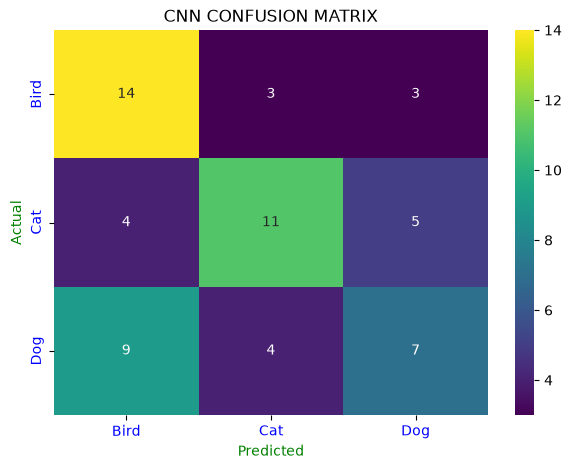

In [68]:
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Bird","Cat","Dog"],
    yticklabels=["Bird","Cat","Dog"])
plt.xticks(color="blue")
plt.yticks(color="blue")
plt.xlabel("Predicted",color="green")
plt.ylabel("Actual",color="green")
plt.title("CNN CONFUSION MATRIX")
plt.show()

In [70]:
model.save("cat_dog_bird_cnn.keras")